# MIGHT example on Wise-1 cancer data

## Import libraries and local functions

In [1]:
!pip install treeple
!pip install torch
!pip install pytorch_tabnet
!pip install scipy

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 MB 43.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 51.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.8 MB/s eta 0:00:0000:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00


In [92]:
# dependency libararies
import warnings
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# treeple functions
import treeple
from treeple.ensemble import HonestForestClassifier, ObliqueRandomForestClassifier
from treeple.tree import ObliqueDecisionTreeClassifier
from treeple.stats import build_oob_forest

warnings.filterwarnings("ignore")

# default list for the results
from collections import defaultdict

# for tabnet
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import roc_auc_score
import scipy
from pathlib import Path
%matplotlib inline

In [3]:
# local function for processing cancer data files
def get_X_y(f, root="./data/", cohort=[], verbose=False):
    df = pd.read_csv(root + f)
    non_features = [
        "Run",
        "Sample",
        "Library",
        "Cancer Status",
        "Tumor type",
        "Stage",
        "Library volume (uL)",
        "Library Volume",
        "UIDs Used",
        "Experiment",
        "P7",
        "P7 Primer",
        "MAF",
    ]
    sample_ids = df["Sample"]
    # if sample is contains "Run" column, remove it
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            sample_ids[i] = sample_id.split(".")[1]
    target = "Cancer Status"
    y = df[target]
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        # filter the rows with cohort1 samples
        X = df[sample_ids.isin(cohort)]
        y = y[sample_ids.isin(cohort)]
    else:
        X = df
    if "Wise" in f:
        # replace nans with zero
        X = X.fillna(0)
    # impute the nan values with the mean of the column
    X = X.fillna(X.mean(axis=0))
    # check if there are nan values
    # nan_rows = X.isnull().any(axis=1)
    nan_cols = X.isnull().all(axis=0)
    # remove the columns with all nan values
    X = X.loc[:, ~nan_cols]
    if verbose:
        if nan_cols.sum() > 0:
            print(f)
            print(f"nan_cols: {nan_cols.sum()}")
            print(f"X shape: {X.shape}, y shape: {y.shape}")
        else:
            print(f)
            print(f"X shape: {X.shape}, y shape: {y.shape}")
    # X = X.dropna()
    # y = y.drop(nan_rows.index)

    return X, y

## Process the Wise-1 cancer data

In [4]:
DIRECTORY = "../cancer_data/ManuscriptFeatureMatrices/"
MODEL_DIR = "./trained_models/"
N_JOBS = 10
N_EST = 100 # 100_000
RANDOM_STATE = 42

# collect sample data
sample_list_file = DIRECTORY + "AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]

# get the sample ids for specific cohorts
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
cohort2 = sample_list[sample_list["cohort"] == "Cohort2"]["sample_id"]
PON = sample_list[sample_list["cohort"] == "PanelOfNormals"]["sample_id"]

In [5]:
# define helper function to log the results
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

def log_results(results, y_test, y_pred, **kwargs):
    """
    results: dictionary to store the results
    """
    results["accuracy"].append(accuracy_score(y_test, y_pred))
    results["roc_auc"].append(roc_auc_score(y_test, y_pred))
    results["f1"].append(f1_score(y_test, y_pred))
    results["precision"].append(precision_score(y_test, y_pred))
    results["recall"].append(recall_score(y_test, y_pred))
    if kwargs:
        for key, value in kwargs.items():
            if key not in results.keys():
                results[key] = []
            results[key].append(value)
    return results

# define helper function to count the number of nodes
def node_count(classifier, forest=False):
    """Records the number of nodes"""
    num_nodes = 0
    if forest:
        for tree in classifier.estimators_:
            num_nodes += tree.tree_.node_count
    else:
        num_nodes = classifier.tree_.node_count

    return num_nodes

In [151]:
# obtain the samples for cohort 1
X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=cohort2)

In [152]:
# get a basic stats of the data
print(X.shape, y.shape)
subset_sizes = [2**i for i in range(3, 9)] + [X.shape[0]]

# define a function to select a subset of the data 
def get_data_subset(X, y, n_samples=1000, seed=RANDOM_STATE):
    # if the number of samples is greater than the number of samples in the data
    if n_samples > X.shape[0]:
        return X, y
    # get the indices of the samples
    np.random.seed(seed)
    idx = np.random.choice(X.shape[0], n_samples, replace=False)
    return X.iloc[idx], y.iloc[idx]

# # get a subset of the data
# X_sub, y_sub = get_data_subset(X, y, n_samples=subset_sizes[-2])
# print(X_sub.shape, y_sub.shape)

(1447, 2523) (1447,)


## Workflow
1. Define the models (RF, SPORF, NN)
2. For each subset size:
    2.1. Split the data into training and testing sets
    2.2. Subset the training data
    2.3. Train the models
    2.4. Evaluate the models
3. Plot the results

## Define the models

In [153]:
RF = HonestForestClassifier(
    n_estimators=N_EST,
    max_samples=1.6,
    max_features=0.3,
    bootstrap=True,
    stratify=True,
    n_jobs=N_JOBS,
    random_state=23,
    honest_prior="ignore"
)

SPORF = HonestForestClassifier(
    n_estimators=N_EST,
    max_samples=1.6,
    max_features=0.3,
    bootstrap=True,
    stratify=True,
    n_jobs=N_JOBS,
    random_state=23,
    honest_prior="ignore",
    tree_estimator=ObliqueDecisionTreeClassifier(),
)


In [ ]:
MODEL_DIR = "./trained_models/"
N_JOBS = 10
N_EST = 6000 # 100_000
RANDOM_STATE = np.random.randint(1000)
TEST_SIZE = 50
print(X.shape, y.shape)
# define the subset sizes in log scale from 8 to X.shape[0]
subset_sizes = [2**i for i in range(3, 9)]
if X.shape[0] `- TEST_SIZE` > subset_sizes[-1]:
    subset_sizes.append(X.shape[0] - TEST_SIZE)
print("subset_sizes: ", subset_sizes)

# define the models
RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

tabnet_params = {
                "n_d":10,
                "optimizer_fn":torch.optim.Adam,
                "optimizer_params":dict(lr=10e-3),
                "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                # "mask_type": "sparsemax"
                #  "grouped_features" : grouped_features
                }

TABNET = TabNetClassifier(**tabnet_params)

MODELS = [RF, SPORF]

# define a dictionary to store the results
results = defaultdict(list)
for subset_size in subset_sizes:
    # split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    # get subset of the training data
    if subset_size < X_train.shape[0]:
        X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE, stratify=y_train)
    else:
        X_train_sub, y_train_sub = X_train, y_train
    # print(X_train_sub.shape, y_train_sub.shape)
    # check if the subset has the both classes
    while len(np.unique(y_train_sub)) < 2 or np.unique(y_train_sub, return_counts=True)[1].min() < 3:
        RANDOM_STATE += 1
        X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE)
        # check the class distribution
    print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_train_sub, return_counts=True)}")
    # define the parameters
    kwargs = {}
    # fit the models
    for est in MODELS:
        kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
        kwargs["cohort"] = "Cohort1"
        kwargs["subset_size"] = subset_size
        base_model = est.__class__.__name__ #if est.tree_estimator is not None else "DescisionTreeClassifier"
        kwargs["base_model"] = base_model
        kwargs["n_estimators"] = N_EST
        kwargs["n_jobs"] = N_JOBS
        kwargs["random_state"] = RANDOM_STATE
        # start time
        start_time = time.perf_counter()
        # obtain tree level posteriors
        # fitted_est, tree_proba = build_oob_forest(est, X_train_sub, y_train_sub)
        fitted_est = est.fit(X_train_sub, y_train_sub)
        # calculate fitting time
        end_time = time.perf_counter()
        time_dif = end_time-start_time
        kwargs["fit_time"] = time_dif
        print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
        # get the posterior probabilities
        posterior = fitted_est.predict_proba(X_test)
        # get the metrics and log the results
        y_pred = np.argmax(posterior, axis=1)
        print(f"Subset size: {subset_size}, Model: {base_model},  Accuracy: {accuracy_score(y_test, y_pred)}")
        # count the number of nodes
        num_nodes = node_count(fitted_est, forest=True)
        kwargs["num_nodes"] = num_nodes
        log_results(results, y_test, y_pred, **kwargs)
        # save the model
        model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
        with open(MODEL_DIR + model_name, "wb", ) as f:
            pickle.dump(fitted_est, f)
        print(f"Model saved: {model_name}")
        # save the results
        results_df = pd.DataFrame(results)
        # check if the file exists and append the results
        file_name = "results.csv"
        # check if the file exists
        if file_name not in os.listdir(MODEL_DIR):
            results_df.to_csv(MODEL_DIR + file_name, index=False)
        else:
            results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
        print("Results saved")

        

## Results

In [102]:
# load the results
results_df = pd.read_csv(MODEL_DIR + "results.csv")
results_df
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[["accuracy", "subset_size", "fit_time", "num_nodes", "n_estimators", "base_model"]]
models = results_df["base_model"].unique()
results_df.head()

,accuracy,subset_size,fit_time,num_nodes,n_estimators,base_model
0,0.766667,8,2.559106,17908,6000,RandomForestClassifier
1,0.766667,8,2.559106,17908,6000,RandomForestClassifier
2,0.700000,8,11.587991,17908,6000,ObliqueRandomForestClassifier
3,0.766667,8,2.559106,17908,6000,RandomForestClassifier
4,0.700000,8,11.587991,17908,6000,ObliqueRandomForestClassifier


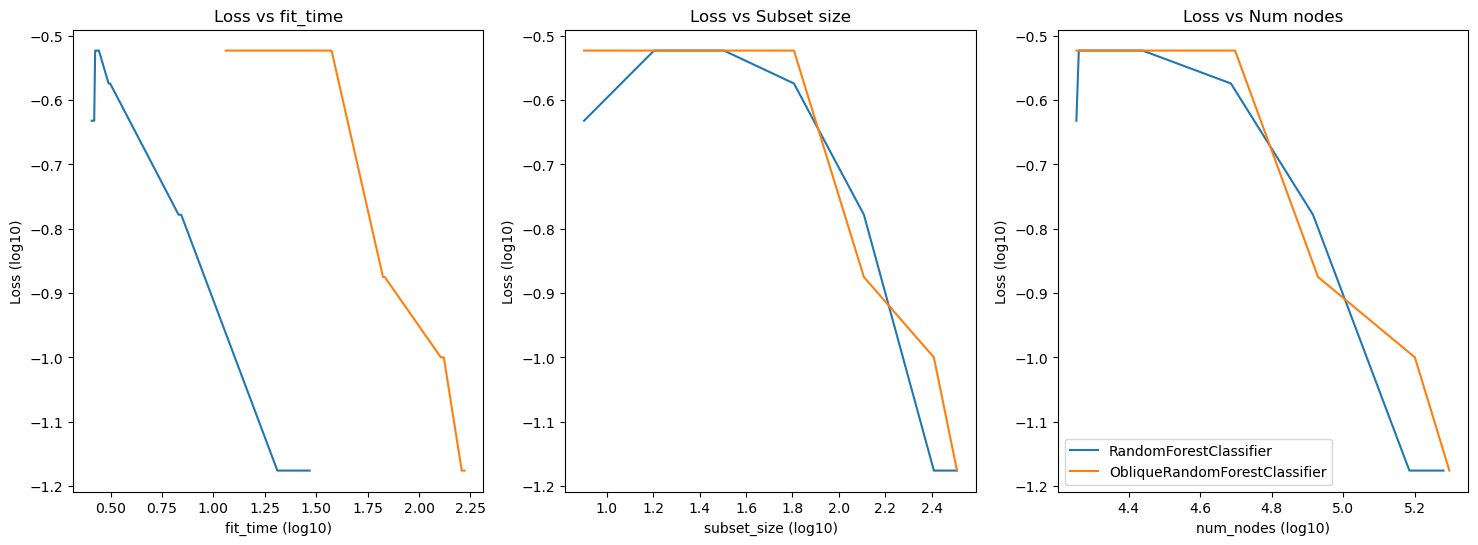

In [ ]:
# plot the three in one plot
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
x_metrics = ["fit_time", "subset_size", "num_nodes"]
y_metrics = ["accuracy", "accuracy", "accuracy"]
titles = ["Loss vs fit_time", "Loss vs Subset size", "Loss vs Num nodes"]
for i, (x_metric, y_metric, title) in enumerate(zip(x_metrics, y_metrics, titles)):
    axs[i].set_xlabel(x_metric+" (log10)")
    axs[i].set_ylabel("Loss (log10)")
    axs[i].set_title(title)
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        df = df.groupby(x_metric).mean().reset_index()
        axs[i].plot(df[x_metric], np.log10(1-df[y_metric]), label=model)
axs[i].legend()

In [134]:
from sre_constants import REPEAT
from tabnanny import verbose
import pandas as pd
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split

subset_sizes = [2**i for i in range(3, 9)]
if X.shape[0] - TEST_SIZE > subset_sizes[-1]:
    subset_sizes.append(X.shape[0] - TEST_SIZE)

tabnet_params = {
                #  "cat_idxs":cat_idxs,
                #  "cat_dims":cat_dims,
                #  "cat_emb_dim":2,
                "n_d":10,
                "optimizer_fn":torch.optim.Adam,
                "optimizer_params":dict(lr=10e-4),
                # "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                #                  "gamma":0.9},
                # "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                # "mask_type": "sparsemax"
                #  "grouped_features" : grouped_features
                }

clf = TabNetClassifier(**tabnet_params)

MODEL_DIR = "./trained_models/"
N_JOBS = 10
# N_EST = 6000 # 100_000
RANDOM_STATE = np.random.randint(1000)
TEST_SIZE = 30
N_D = 8
LR = 10e-4
REPEAT = 10
MAX_ITER = 100

# define the models
# RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

# SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

tabnet_params = {
                "n_d":N_D,
                "n_a":N_D,
                "optimizer_fn":torch.optim.Adam,
                "optimizer_params":dict(lr=LR),
                "scheduler_params":{"step_size":100, # how to use learning rate scheduler
                                 "gamma":0.9},
                "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                "verbose":0
                }

TABNET = TabNetClassifier(**tabnet_params)

MODELS = [TABNET]

# define a dictionary to store the results
results = defaultdict(list)
for N_D in [8, 16, 32, 64]:
    for i in range(REPEAT):
        tabnet_params = {
                    "n_d":N_D,
                    "n_a":N_D,
                    "optimizer_fn":torch.optim.Adam,
                    "optimizer_params":dict(lr=LR),
                    "scheduler_params":{"step_size":100, # how to use learning rate scheduler
                                    "gamma":0.9},
                    "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                    "verbose":0
                    }

        TABNET = TabNetClassifier(**tabnet_params)
        for subset_size in subset_sizes:
            RANDOM_STATE = np.random.randint(1000)
            # split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
            # get subset of the training data
            if subset_size < X_train.shape[0]:
                X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE, stratify=y_train)
            else:
                X_train_sub, y_train_sub = X_train, y_train
            # print(X_train_sub.shape, y_train_sub.shape)
            # check if the subset has the both classes
            while len(np.unique(y_train_sub)) < 2 or np.unique(y_train_sub, return_counts=True)[1].min() < 3:
                RANDOM_STATE += 1
                X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE)
                # check the class distribution
            # print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_train_sub, return_counts=True)}")
            # define the parameters
            kwargs = {}
            # fit the models
            for est in MODELS:
                kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
                kwargs["cohort"] = "Cohort1"
                kwargs["subset_size"] = subset_size
                kwargs["n_d"] = tabnet_params["n_d"]
                kwargs["lr"] = tabnet_params["optimizer_params"]["lr"]
                # kwargs["n_a"] = tabnet_params["n_a"]
                base_model = est.__class__.__name__ #if est.tree_estimator is not None else "DescisionTreeClassifier"
                kwargs["base_model"] = base_model
                # kwargs["n_estimators"] = N_EST
                # kwargs["n_jobs"] = N_JOBS
                kwargs["random_state"] = RANDOM_STATE
                # start time
                start_time = time.perf_counter()
                fitted_est = est.fit(X_train_sub.values, y_train_sub.values, max_epochs=MAX_ITER)
                # calculate fitting time
                end_time = time.perf_counter()
                time_dif = end_time-start_time
                kwargs["fit_time"] = time_dif
                if i == 9:
                    print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
                # get the posterior probabilities
                # posterior = fitted_est.predict_proba(X_test.values)
                # get the metrics and log the results
                # y_pred = np.argmax(posterior, axis=1)
                y_pred = est.predict(X_test.values)
                if i == 9:
                    print(f"Subset size: {subset_size}, Model: {base_model},  Accuracy: {accuracy_score(y_test, y_pred)}")
                # count the number of nodes
                # num_nodes = node_count(fitted_est, forest=True)
                # kwargs["num_nodes"] = num_nodes
                log_results(results, y_test, y_pred, **kwargs)
                # save the model
                # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
                # with open(MODEL_DIR + model_name, "wb", ) as f:
                #     pickle.dump(fitted_est, f)
                # print(f"Model saved: {model_name}")
                # save the results
                results_df = pd.DataFrame(results)
                # check if the file exists and append the results
                file_name = "results_tab.csv"
                # check if the file exists
                if file_name not in os.listdir(MODEL_DIR):
                    results_df.to_csv(MODEL_DIR + file_name, index=False)
                else:
                    results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
                # print("Results saved")


Subset size: 8, Model: TabNetClassifier, Time: 0.06459658313542604
Subset size: 8, Model: TabNetClassifier,  Accuracy: 0.43333333333333335
Subset size: 16, Model: TabNetClassifier, Time: 0.06815474992617965
Subset size: 16, Model: TabNetClassifier,  Accuracy: 0.5333333333333333
Subset size: 32, Model: TabNetClassifier, Time: 0.06594345765188336
Subset size: 32, Model: TabNetClassifier,  Accuracy: 0.5
Subset size: 64, Model: TabNetClassifier, Time: 0.08141124993562698
Subset size: 64, Model: TabNetClassifier,  Accuracy: 0.5666666666666667
Subset size: 128, Model: TabNetClassifier, Time: 0.07630958314985037
Subset size: 128, Model: TabNetClassifier,  Accuracy: 0.6333333333333333
Subset size: 256, Model: TabNetClassifier, Time: 0.09173208335414529
Subset size: 256, Model: TabNetClassifier,  Accuracy: 0.5
Subset size: 322, Model: TabNetClassifier, Time: 0.10010325023904443
Subset size: 322, Model: TabNetClassifier,  Accuracy: 0.4666666666666667
Subset size: 8, Model: TabNetClassifier, Time

In [ ]:
clf.

AttributeError: 'TabNetClassifier' object has no attribute 'network'

AttributeError: 'TabNetClassifier' object has no attribute 'parameter'